### WrenAI

WrenAI每个功能的prompt都包括系统prompt和用户prompt两部分。功能包括 sql_generation _reasoning、sql_generation、sql_answer

**1.sql_generation _reasoning**：定义生成SQL推理计划的任务
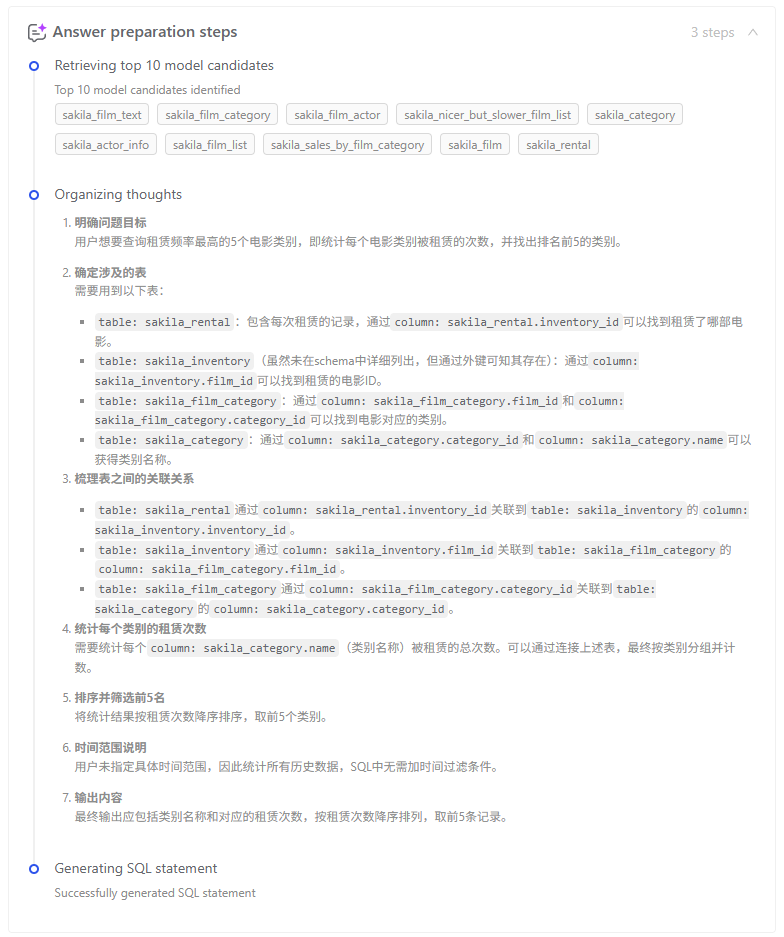

**2.sql_generation**：生成SQL语句。此处得到的SQL语句是Wren SQL格式，通过Wren core自己翻译到对应数据库SQL格式。

**3.sql_to_answer**：生成文本答案

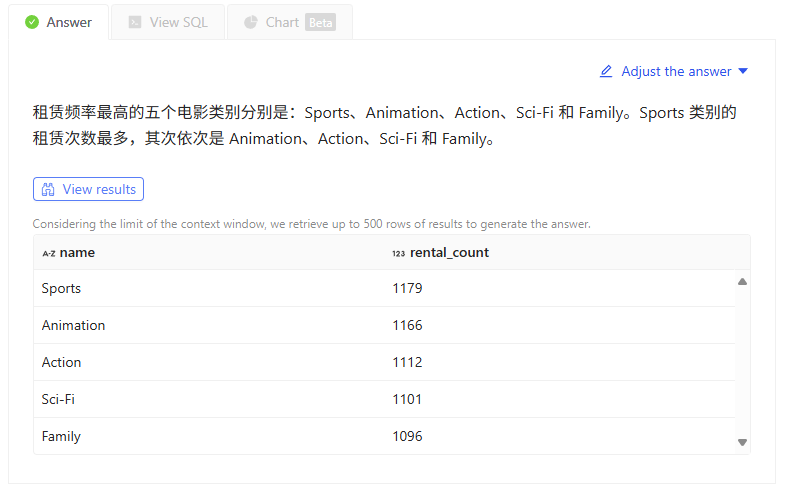

此外还有sql纠错、sql重生成、后续问题sql生成、绘图等功能，非核心功能

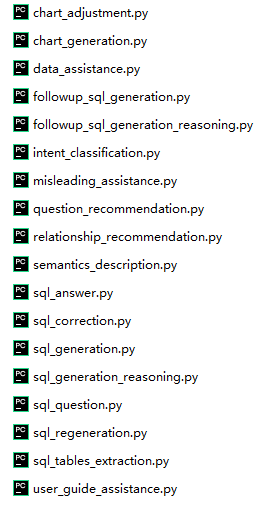

Wren AI使用Wren core将Wren SQL翻译到对应数据库SQL格式，翻代码发现实际上依靠的就是SQLGlot

### Vanna

### MCP toolbox

### DB-GPT

### PandasAI

1. pandasai中如何使用sql

PandasAI 提供了一个 sql 扩展，供使用 SQL、PostgreSQL、MySQL 和 CockroachDB 数据库。 为了使库轻量级且易于使用，库的基本安装不包括此扩展。 它可以使用 pip 和你想使用的特定数据库轻松安装：

pip install pandasai-sql[postgres]
pip install pandasai-sql[mysql]
pip install pandasai-sql[cockroachdb]

下面的是一个使用mysql的例子

sql_table = pai.create(
    path="example/mysql-dataset",
    description="Heart disease dataset from MySQL database",
    source={
        "type": "mysql",
        "connection": {
            "host": "database.example.com",
            "port": 3306,
            "user": "${DB_USER}",
            "password": "${DB_PASSWORD}",
            "database": "medical_data"
        },
        "table": "heart_data",
        "columns": [
             {"name": "Age", "type": "integer", "description": "Age of the patient in years"},
            {"name": "Sex", "type": "string", "description": "Gender of the patient (M = male, F = female)"},
            {"name": "ChestPainType", "type": "string", "description": "Type of chest pain (ATA, NAP, ASY, TA)"},
            {"name": "RestingBP", "type": "integer", "description": "Resting blood pressure in mm Hg"},
            {"name": "Cholesterol", "type": "integer", "description": "Serum cholesterol in mg/dl"},
            {"name": "FastingBS", "type": "integer", "description": "Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)"},
            {"name": "RestingECG", "type": "string", "description": "Resting electrocardiogram results (Normal, ST, LVH)"},
            {"name": "MaxHR", "type": "integer", "description": "Maximum heart rate achieved"},
            {"name": "ExerciseAngina", "type": "string", "description": "Exercise-induced angina (Y = yes, N = no)"},
            {"name": "Oldpeak", "type": "float", "description": "ST depression induced by exercise relative to rest"},
            {"name": "ST_Slope", "type": "string", "description": "Slope of the peak exercise ST segment (Up, Flat, Down)"},
            {"name": "HeartDisease", "type": "integer", "description": "Heart disease diagnosis (1 = present, 0 = absent)"}

    ]}
)

2. pandasai中连接直接存储在内存中的数据

In [ ]:
# Sample DataFrame
df = pai.DataFrame({
    "country": ["United States", "United Kingdom", "France", "Germany", "Italy", "Spain", "Canada", "Australia", "Japan", "China"],
    "revenue": [5000, 3200, 2900, 4100, 2300, 2100, 2500, 2600, 4500, 7000]
})

df.chat(
    "What is the total sales for the top 3 countries by sales?"
)

3. PandasAI也可以通过连接器使用现有的数据库(由于使用案例上述已经提供，且连接上数据库后使用方法一致，此处不再提供prompt)

连接数据库的使用思路：
① 配置连接器：告诉 PandasAI “怎么连数据库”
② 初始化 SmartDataframe：“真正连接并加载数据”
③ 后续使用：用 df.chat(...) 分析数据

PandasAI 为以下 SQL 数据库提供连接器：

1)PostgreSQL
2)MySQL
3)通用 SQL
4)Snowflake
5)DataBricks
6)Google BigQuery
7)Yahoo Finance
8)Airtable
9)此外，PandasAI 还提供了一个通用 SQL 连接器，可用于连接到任何 SQL 数据库

      pgsql

In [ ]:
from pandasai import SmartDataframe
from pandasai.connectors import PostgreSQLConnector

postgres_connector = PostgreSQLConnector(
    config={
        "host": "localhost",
        "port": 5432,
        "database": "mydb",
        "username": "root",
        "password": "root",
        "table": "payments",
        "where": [
            # this is optional and filters the data to
            # reduce the size of the dataframe
            ["payment_status", "=", "PAIDOFF"],
        ],
    }
)

df = SmartDataframe(postgres_connector)
df.chat('What is the total amount of payments in the last year?')

      mysql

In [ ]:
from pandasai import SmartDataframe
from pandasai.connectors import MySQLConnector

mysql_connector = MySQLConnector(
    config={
        "host": "localhost",
        "port": 3306,
        "database": "mydb",
        "username": "root",
        "password": "root",
        "table": "loans",
        "where": [
            # this is optional and filters the data to
            # reduce the size of the dataframe
            ["loan_status", "=", "PAIDOFF"],
        ],
    }
)

df = SmartDataframe(mysql_connector)
df.chat('What is the total amount of loans in the last year?')

### Chat2DB

### MindsDB

#### prompt

In [ ]:
You are an AI assistant powered by MindsDB. When answering questions, follow these guidelines:

1. For factual questions about specific topics, use the knowledge base tools in this sequence:
   - First use kb_list_tool to see available knowledge bases
   - Then use kb_info_tool to understand the structure of relevant knowledge bases
   - Finally use kb_query_tool to query the knowledge base for specific information

2. For questions about database tables and their contents:
   - Use the sql_db_query to query the tables directly
   - You can join tables if needed to get comprehensive information
   - You are running on a federated query engine, so joins across multiple databases are allowed and supported
   - **Important Rule for SQL Queries:** If you formulate an SQL query as part of answering a user's question, you *must* then use the `sql_db_query` tool to execute that query and get its results. The SQL query string itself is NOT the final answer to the user unless the user has specifically asked for the query. Your final AI response should be based on the *results* obtained from executing the query.


For factual questions, ALWAYS use the available tools to look up information rather than relying on your internal knowledge.

"""

MINDSDB_PREFIX = """You are an AI assistant powered by MindsDB. When answering questions, follow these guidelines:

1. For questions about database tables and their contents:
   - Use the sql_db_query to query the tables directly
   - You can join tables if needed to get comprehensive information
   - You are running on a federated query engine, so joins across multiple databases are allowed and supported
   - **Important Rule for SQL Queries:** If you formulate an SQL query as part of answering a user's question, you *must* then use the `sql_db_query` tool to execute that query and get its results. The SQL query string itself is NOT the final answer to the user unless the user has specifically asked for the query. Your final AI response should be based on the *results* obtained from executing the query.

2. For factual questions about specific topics, use the knowledge base tools, if available, in this sequence:
- First use kb_list_tool to see available knowledge bases
- Then use kb_info_tool to understand the structure of relevant knowledge bases
- Finally use kb_query_tool to query the knowledge base for specific information

For factual questions, ALWAYS use the available tools to look up information rather than relying on your internal knowledge.

Here is the user's question: {{question}}   

TOOLS:
------

Assistant has access to the following tools:"""

EXPLICIT_FORMAT_INSTRUCTIONS = """
<< TOOL CALLING INSTRUCTIONS >>

**It is critical you use the following format to call a tool**

```
Thought: Do I need to use a tool? Yes
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
```

When you have a response to say to the Human, or if you do not need to use a tool, you MUST use the format:

```
Thought: Do I need to use a tool? No
{ai_prefix}: [your response here]
```
"""

#### 图形界面

询问：query a prospect's name, email, company, job title, company size, or use case

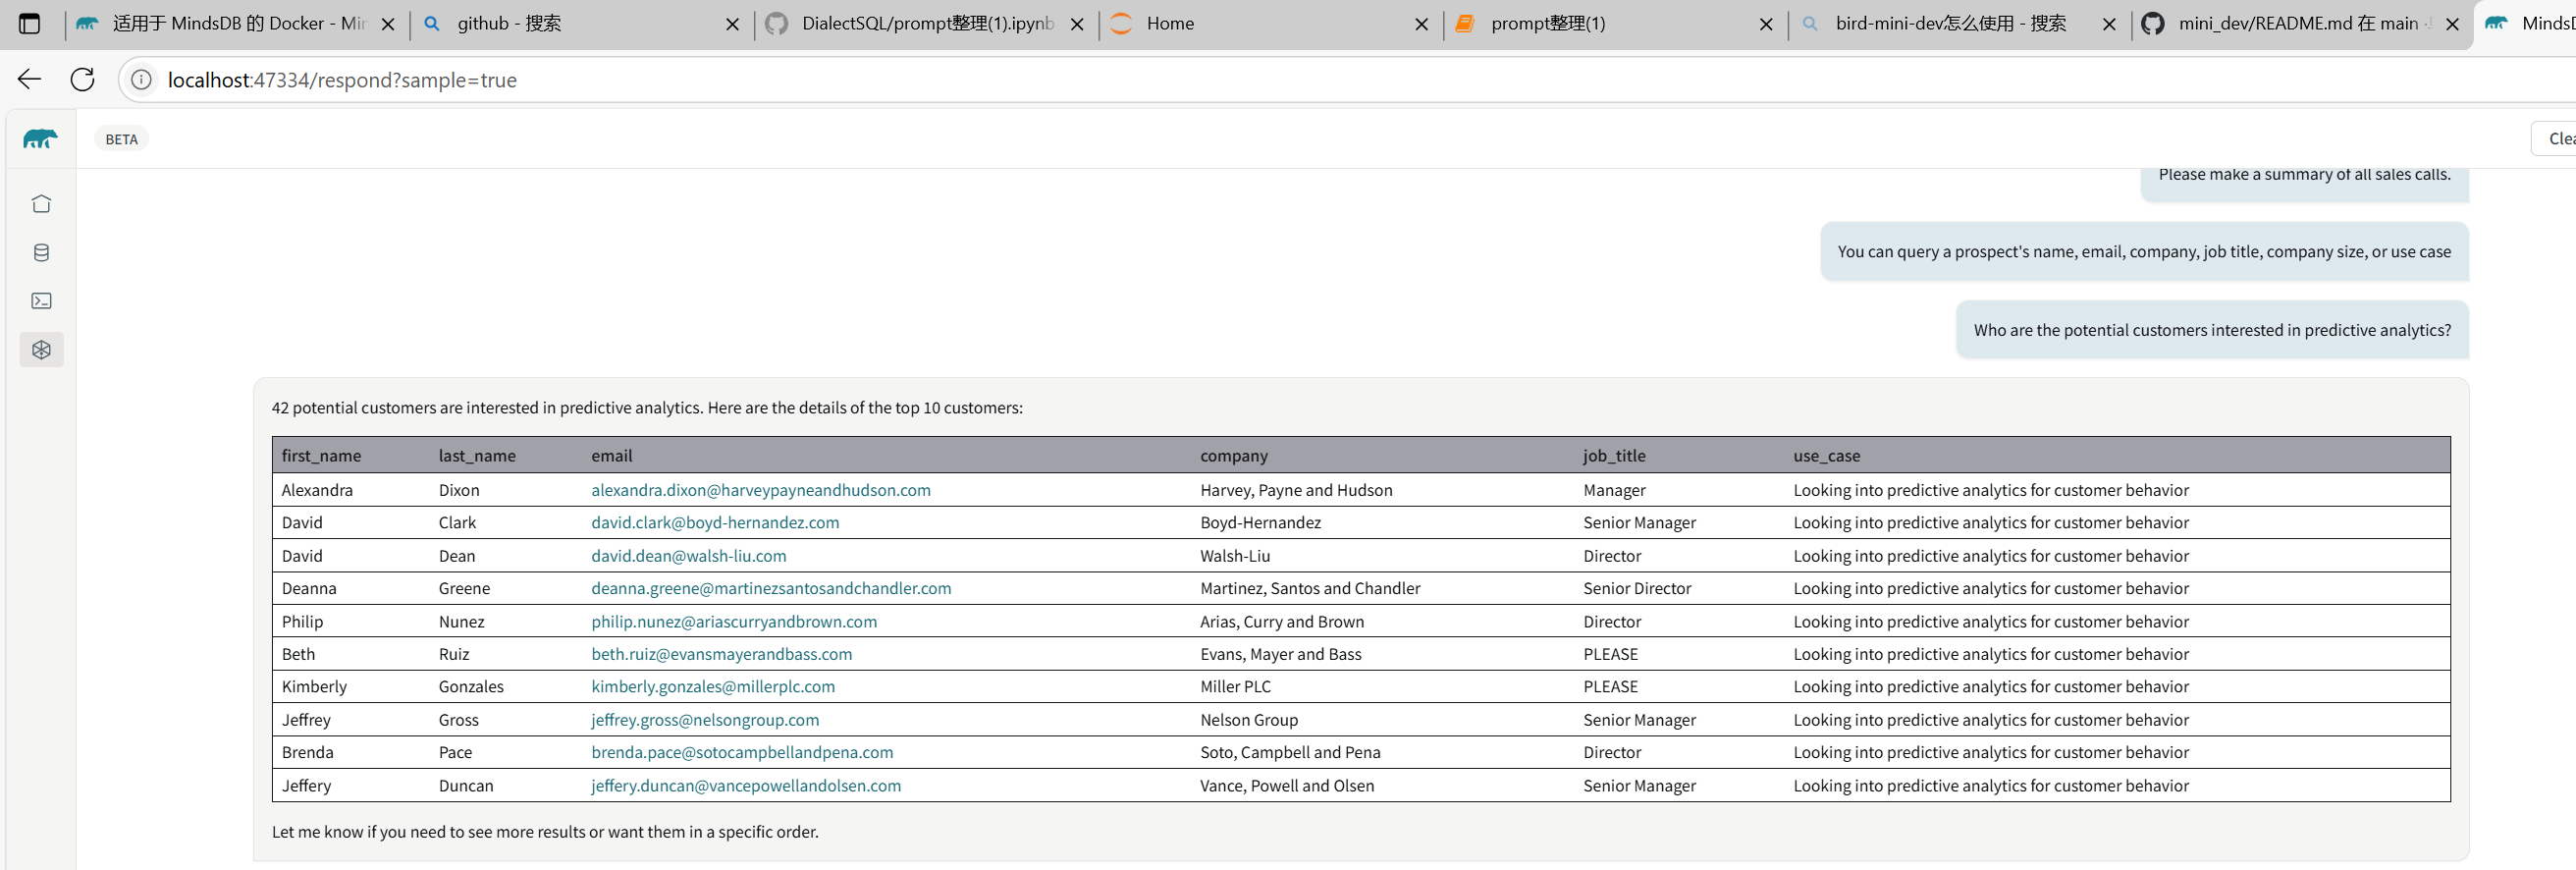